In [ ]:
# ============================================================
# 1일차 오전: BPE → Self-Attention 시각화 → Positional Encoding
# 프레임워크: Keras (TF 2.x)  |  토크나이저: HuggingFace tokenizers
# 목표: 오후 Decoder-only 추론의 개념 기반 구축
# ============================================================

!pip install -q tokenizers transformers tensorflow matplotlib seaborn koreanize-matplotlib

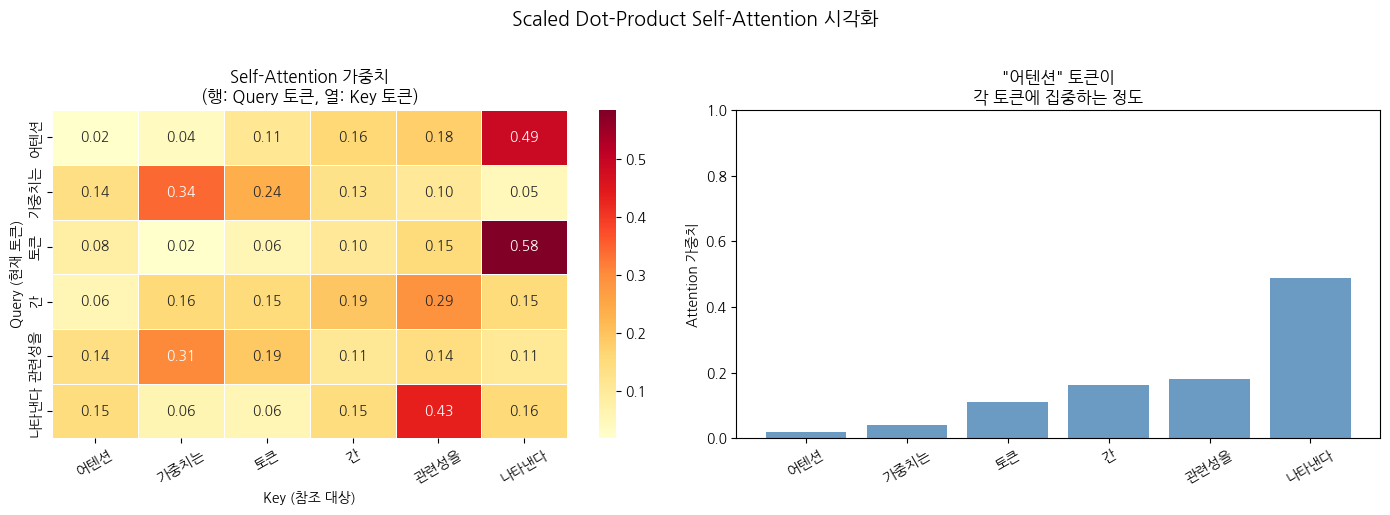

★ 읽는 법: 행(Query 토큰)이 열(Key 토큰)을 얼마나 참고하는지를 색 농도로 표현
★ RAG 연결: 질문 토큰이 문서 토큰 중 어느 부분에 집중하는지 — 같은 원리


In [1]:
# ────────────────────────────────────────────────────────────
# 블록 2: Self-Attention 시각화 (50분)
# Keras로 직접 구현 + 가중치 히트맵
# ────────────────────────────────────────────────────────────
import numpy as np
import tensorflow as tf
from tensorflow import keras
import koreanize_matplotlib  # matplotlib에서 한글 깨짐 방지
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib


matplotlib.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False

## 2-1. Scaled Dot-Product Attention — Keras 직접 구현
class ScaledDotProductAttention(keras.layers.Layer):
    """
    Q(Query), K(Key), V(Value) 행렬로 Attention 계산
    score = softmax(QK^T / sqrt(d_k)) * V
    """
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, q, k, v, mask=None):
        d_k = tf.cast(tf.shape(k)[-1], tf.float32)
        # Attention score: QK^T / sqrt(d_k)
        scores = tf.matmul(q, k, transpose_b=True) / tf.math.sqrt(d_k)
        if mask is not None:
            scores += (mask * -1e9)   # 마스킹 위치 → -∞
        weights = tf.nn.softmax(scores, axis=-1)
        output  = tf.matmul(weights, v)
        return output, weights

## 2-2. Self-Attention 레이어 (Q=K=V=같은 입력)
class SelfAttentionLayer(keras.layers.Layer):
    def __init__(self, d_model, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.wq = keras.layers.Dense(d_model, use_bias=False, name="W_Q")
        self.wk = keras.layers.Dense(d_model, use_bias=False, name="W_K")
        self.wv = keras.layers.Dense(d_model, use_bias=False, name="W_V")
        self.attn = ScaledDotProductAttention()

    def call(self, x, mask=None):
        q = self.wq(x)
        k = self.wk(x)
        v = self.wv(x)
        out, weights = self.attn(q, k, v, mask)
        return out, weights

## 2-3. 토큰 임베딩 준비
tokens = ["어텐션", "가중치는", "토큰", "간", "관련성을", "나타낸다"]
seq_len = len(tokens)
d_model = 16   # 시각화 목적의 작은 차원

# 랜덤 임베딩 (실제 학습 없이 개념 시연용)
tf.random.set_seed(42)
x = tf.random.normal([1, seq_len, d_model])   # (batch=1, seq, d_model)

## 2-4. Self-Attention 실행 + 가중치 추출
self_attn = SelfAttentionLayer(d_model=d_model)
output, attn_weights = self_attn(x)

weights_np = attn_weights.numpy()[0]   # (seq_len, seq_len)

## 2-5. ★ 가중치 히트맵 시각화 — 핵심 시연 장면
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Attention 가중치 히트맵
sns.heatmap(
    weights_np,
    xticklabels=tokens,
    yticklabels=tokens,
    annot=True, fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("Self-Attention 가중치\n(행: Query 토큰, 열: Key 토큰)", fontsize=12)
axes[0].set_xlabel("Key (참조 대상)")
axes[0].set_ylabel("Query (현재 토큰)")
axes[0].tick_params(axis='x', rotation=30)

# 오른쪽: 특정 토큰("어텐션")의 Attention 분포
attn_for_token0 = weights_np[0]
axes[1].bar(tokens, attn_for_token0, color='steelblue', alpha=0.8)
axes[1].set_title(f'"{tokens[0]}" 토큰이\n각 토큰에 집중하는 정도', fontsize=12)
axes[1].set_ylabel("Attention 가중치")
axes[1].tick_params(axis='x', rotation=30)
axes[1].set_ylim(0, 1)

plt.suptitle("Scaled Dot-Product Self-Attention 시각화", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("attention_visualization.png", dpi=150, bbox_inches='tight')
plt.show()

print("★ 읽는 법: 행(Query 토큰)이 열(Key 토큰)을 얼마나 참고하는지를 색 농도로 표현")
print("★ RAG 연결: 질문 토큰이 문서 토큰 중 어느 부분에 집중하는지 — 같은 원리")